# Projet 11 - Analyse des Discours Politiques
## Etape 2 : Vectorisation + Modelisation + Evaluation
**Master 1 IA and Data Science**

Structure attendue dans Google Drive :
```
Mon Drive/NLP_Project/
    outputs/
        ds1_global_political_clean.csv
        ds2_ukraine_conflict_clean.csv
        ds3_us_election_2020_clean.csv
    models/
    reports/     
```
---

## Cellule 1 - Montage Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive monte avec succes.')

Mounted at /content/drive
Google Drive monte avec succes.


## Cellule 2 - Installation des dependances

In [2]:
import subprocess, sys

PACKAGES = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn',
    'nltk', 'vaderSentiment', 'mlflow', 'joblib', 'wordcloud',
    'imbalanced-learn'
]

print('Installation des dependances...')
for pkg in PACKAGES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])
print('Toutes les dependances sont installees.')

Installation des dependances...
Toutes les dependances sont installees.


## Cellule 3 - Imports et ressources NLTK

In [3]:
import os, re, warnings, joblib
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model     import LogisticRegression
from sklearn.naive_bayes      import MultinomialNB
from sklearn.svm              import LinearSVC
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling   import SMOTE
import mlflow
import mlflow.sklearn

import nltk
for r in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab', 'vader_lexicon']:
    nltk.download(r, quiet=True)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Imports OK


## Cellule 4 - Configuration des chemins

In [4]:
GDRIVE_ROOT = Path('/content/drive/MyDrive/NLP_Project')

OUTPUT_DIR  = GDRIVE_ROOT / 'outputs'
MODELS_DIR  = GDRIVE_ROOT / 'models'
REPORTS_DIR = GDRIVE_ROOT / 'reports'

for d in [MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DS1_PATH = OUTPUT_DIR / 'ds1_global_political_clean.csv'
DS2_PATH = OUTPUT_DIR / 'ds2_ukraine_conflict_clean.csv'
DS3_PATH = OUTPUT_DIR / 'ds3_us_election_2020_clean.csv'

print('Chemins configures :')
for label, path in [('DS1', DS1_PATH), ('DS2', DS2_PATH), ('DS3', DS3_PATH)]:
    status = 'OK' if path.exists() else 'MANQUANT'
    print(f'  {label:8s} : {status}')

Chemins configures :
  DS1      : OK
  DS2      : OK
  DS3      : OK


## Cellule 5 - Chargement et preparation des donnees

In [5]:
print('Chargement des donnees...')

frames = []
for path, name in [(DS1_PATH, 'DS1'), (DS2_PATH, 'DS2'), (DS3_PATH, 'DS3')]:
    if path.exists():
        tmp = pd.read_csv(path, low_memory=False)
        frames.append(tmp)
        print(f'  {name} : {len(tmp):,} lignes')
    else:
        print(f'  {name} : MANQUANT - ignore')

df = pd.concat(frames, ignore_index=True)
df = df.dropna(subset=['tweet_tokens', 'sentiment_label'])
df = df[df['tweet_tokens'].str.strip() != '']
df = df[df['tweet_tokens'].str.split().str.len() >= 3]

label_map   = {'positive': 2, 'neutral': 1, 'negative': 0}
label_names = ['negative', 'neutral', 'positive']
df['label'] = df['sentiment_label'].map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(f'Dataset total apres nettoyage : {len(df):,} lignes')
print('Distribution des labels :')
print(df['sentiment_label'].value_counts())

X = df['tweet_tokens'].values
y = df['label'].values

Chargement des donnees...
  DS1 : 238,422 lignes
  DS2 : 767 lignes
  DS3 : 1,456,644 lignes
Dataset total apres nettoyage : 1,678,802 lignes
Distribution des labels :
sentiment_label
neutral     605220
positive    579283
negative    494299
Name: count, dtype: int64


## Cellule 6 - Echantillonnage stratifie (max 200k par classe)

In [6]:
MAX_PER_CLASS = 200_000
print(f'Echantillonnage : max {MAX_PER_CLASS:,} tweets par classe...')

idx_per_class = []
for cls in [0, 1, 2]:
    idx = np.where(y == cls)[0]
    if len(idx) > MAX_PER_CLASS:
        idx = np.random.RandomState(42).choice(idx, MAX_PER_CLASS, replace=False)
    idx_per_class.append(idx)

sampled_idx = np.concatenate(idx_per_class)
np.random.RandomState(42).shuffle(sampled_idx)

X_sampled = X[sampled_idx]
y_sampled = y[sampled_idx]

print(f'Taille apres echantillonnage : {len(X_sampled):,}')
unique, counts = np.unique(y_sampled, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {label_names[u]:10s} : {c:,}')

Echantillonnage : max 200,000 tweets par classe...
Taille apres echantillonnage : 600,000
  negative   : 200,000
  neutral    : 200,000
  positive   : 200,000


## Cellule 7 - Split Train / Validation / Test (70 / 15 / 15)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sampled, y_sampled,
    test_size=0.30, random_state=42, stratify=y_sampled
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train      : {len(X_train):,} tweets')
print(f'Validation : {len(X_val):,}  tweets')
print(f'Test       : {len(X_test):,}  tweets')

Train      : 420,000 tweets
Validation : 90,000  tweets
Test       : 90,000  tweets


## Cellule 8 - Vectorisation TF-IDF (bigrammes, 50 000 features)

In [8]:
print('Vectorisation TF-IDF...')

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=3,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Vocabulaire TF-IDF : {len(tfidf.vocabulary_):,} features')
print(f'Matrice train      : {X_train_tfidf.shape}')

joblib.dump(tfidf, MODELS_DIR / 'tfidf_vectorizer.pkl')
print('Vectoriseur sauvegarde.')

Vectorisation TF-IDF...
Vocabulaire TF-IDF : 50,000 features
Matrice train      : (420000, 50000)
Vectoriseur sauvegarde.


## Cellule 9 - Definition des 5 modeles

In [9]:
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs',
        multi_class='multinomial', random_state=42, n_jobs=-1
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'LinearSVC': LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, random_state=42,
        n_jobs=-1, class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ),
}

print(f'{len(MODELS)} modeles definis :')
for name in MODELS:
    print(f'  - {name}')

5 modeles definis :
  - Logistic Regression
  - Naive Bayes
  - LinearSVC
  - Random Forest
  - Gradient Boosting


## Cellule 10 - Entrainement, evaluation et tracking MLflow

In [10]:
# ============================================================
# CELLULE 10 - Entrainement, evaluation et tracking MLflow
# ============================================================

import os
from tqdm import tqdm   # <-- Barre de progression

os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

mlflow.set_tracking_uri('file://' + str(GDRIVE_ROOT / 'mlruns'))
mlflow.set_experiment('Projet11_Sentiment_Analysis')

results    = {}
best_model = None
best_f1    = 0.0

print('Entrainement et evaluation des modeles...')
print()

# MODÈLES (Gradient Boosting allégé)
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs',
        multi_class='multinomial', random_state=42, n_jobs=-1
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'LinearSVC': LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=20, random_state=42,
        n_jobs=-1, class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=50,       # <-- Réduit (était 100)
        max_depth=3,           # <-- Réduit (était 5)
        learning_rate=0.1,
        random_state=42,
        verbose=0              # <- Pas de logs
    ),
}

for model_name, model in tqdm(MODELS.items(), desc="Entrainement", unit="modele"):
    print(f'  Entrainement : {model_name}...')

    # Activer verbose pour les modèles qui le supportent
    if hasattr(model, 'verbose') and model_name != 'Gradient Boosting':
        model.verbose = 1

    with mlflow.start_run(run_name=model_name):
        t0 = datetime.now()
        model.fit(X_train_tfidf, y_train)
        train_time = (datetime.now() - t0).total_seconds()

        y_pred_val  = model.predict(X_val_tfidf)
        y_pred_test = model.predict(X_test_tfidf)

        acc_val  = accuracy_score(y_val,  y_pred_val)
        f1_val   = f1_score(y_val,  y_pred_val,  average='weighted')
        acc_test = accuracy_score(y_test, y_pred_test)
        f1_test  = f1_score(y_test, y_pred_test, average='weighted')

        report = classification_report(
            y_test, y_pred_test, target_names=label_names, output_dict=True
        )
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(
            model, X_train_tfidf, y_train,
            cv=cv, scoring='f1_weighted', n_jobs=-1
        )

        mlflow.log_param('model_name',     model_name)
        mlflow.log_param('tfidf_features', len(tfidf.vocabulary_))
        mlflow.log_param('train_size',     len(X_train))
        mlflow.log_metric('accuracy_val',  acc_val)
        mlflow.log_metric('f1_val',        f1_val)
        mlflow.log_metric('accuracy_test', acc_test)
        mlflow.log_metric('f1_test',       f1_test)
        mlflow.log_metric('cv_f1_mean',    cv_scores.mean())
        mlflow.log_metric('cv_f1_std',     cv_scores.std())
        mlflow.log_metric('train_time_s',  train_time)
        mlflow.sklearn.log_model(model, model_name.replace(' ', '_'))

        results[model_name] = {
            'acc_val':    round(acc_val,  4),
            'f1_val':     round(f1_val,   4),
            'acc_test':   round(acc_test, 4),
            'f1_test':    round(f1_test,  4),
            'cv_mean':    round(cv_scores.mean(), 4),
            'cv_std':     round(cv_scores.std(),  4),
            'train_time': round(train_time, 2),
            'report':     report,
            'y_pred':     y_pred_test,
            'model':      model,
        }
        if f1_test > best_f1:
            best_f1    = f1_test
            best_model = model_name

        print(f'    Acc test : {acc_test:.4f}  |  F1 test : {f1_test:.4f}'
              f'  |  CV F1 : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}'
              f'  |  Temps : {train_time:.1f}s')

print()
print(f'Meilleur modele : {best_model} (F1 test = {best_f1:.4f})')
joblib.dump(results[best_model]['model'], MODELS_DIR / 'best_model.pkl')
print('Modele sauvegarde : best_model.pkl')

Entrainement et evaluation des modeles...



Entrainement:   0%|          | 0/5 [00:00<?, ?modele/s]

  Entrainement : Logistic Regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
2026/06/24 07:23:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Entrainement:  20%|██        | 1/5 [02:54<11:39, 174.79s/modele]

    Acc test : 0.8824  |  F1 test : 0.8821  |  CV F1 : 0.8739 +/- 0.0009  |  Temps : 37.3s
  Entrainement : Naive Bayes...


...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   15.5s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    2.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    2.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.9s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.9s finished
2026/06/24 07:33:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Entrainement:  80%|████████  | 4/5 [13:17<03:57, 237.58s/modele]

    Acc test : 0.7021  |  F1 test : 0.6994  |  CV F1 : 0.6962 +/- 0.0025  |  Temps : 65.0s
  Entrainement : Gradient Boosting...


2026/06/24 08:22:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Entrainement: 100%|██████████| 5/5 [1:02:10<00:00, 746.09s/modele] 

    Acc test : 0.6171  |  F1 test : 0.6168  |  CV F1 : 0.6153 +/- 0.0028  |  Temps : 645.7s

Meilleur modele : LinearSVC (F1 test = 0.8902)


Modele sauvegarde : best_model.pkl


## Cellule 10b - MLflow Model Registry (enregistrement officiel)

In [11]:
# Enregistrement officiel du meilleur modele dans le MLflow Model Registry
print('Enregistrement du meilleur modele dans le MLflow Model Registry...')
print(f'Modele : {best_model}')
print(f'F1 Test : {best_f1:.4f}')
print()

MLFLOW_TRACKING_URI = 'file://' + str(GDRIVE_ROOT / 'mlruns')
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

with mlflow.start_run(run_name=f'BEST_MODEL_{best_model.replace(" ", "_")}') as run:
    # Parametres
    mlflow.log_param('model_name',         best_model)
    mlflow.log_param('tfidf_features',     len(tfidf.vocabulary_))
    mlflow.log_param('tfidf_ngram_range',  '(1, 2)')
    mlflow.log_param('train_size',         len(X_train))
    mlflow.log_param('val_size',           len(X_val))
    mlflow.log_param('test_size',          len(X_test))
    mlflow.log_param('max_per_class',      MAX_PER_CLASS)
    mlflow.log_param('label_names',        str(label_names))

    # Metriques finales
    mlflow.log_metric('accuracy_val',  results[best_model]['acc_val'])
    mlflow.log_metric('f1_val',        results[best_model]['f1_val'])
    mlflow.log_metric('accuracy_test', results[best_model]['acc_test'])
    mlflow.log_metric('f1_test',       results[best_model]['f1_test'])
    mlflow.log_metric('cv_f1_mean',    results[best_model]['cv_mean'])
    mlflow.log_metric('cv_f1_std',     results[best_model]['cv_std'])
    mlflow.log_metric('train_time_s',  results[best_model]['train_time'])

    # Metriques par classe (precision, recall, f1 pour negative/neutral/positive)
    report_best = results[best_model]['report']
    for cls in label_names:
        mlflow.log_metric(f'precision_{cls}', report_best[cls]['precision'])
        mlflow.log_metric(f'recall_{cls}',    report_best[cls]['recall'])
        mlflow.log_metric(f'f1_{cls}',        report_best[cls]['f1-score'])

    # Enregistrer le vectoriseur TF-IDF comme artifact
    tfidf_tmp = '/tmp/tfidf_vectorizer.pkl'
    joblib.dump(tfidf, tfidf_tmp)
    mlflow.log_artifact(tfidf_tmp, artifact_path='preprocessors')

    # Enregistrer le rapport de classification comme artifact
    report_tmp = '/tmp/classification_report.txt'
    with open(report_tmp, 'w') as f:
        from sklearn.metrics import classification_report as cr
        f.write(f'MEILLEUR MODELE : {best_model}\n')
        f.write(f'F1 Test         : {best_f1:.4f}\n\n')
        f.write(cr(y_test, results[best_model]['y_pred'], target_names=label_names))
    mlflow.log_artifact(report_tmp, artifact_path='reports')

    # Enregistrer le modele avec son nom dans le Model Registry
    model_info = mlflow.sklearn.log_model(
        sk_model=results[best_model]['model'],
        artifact_path='sentiment_model',
        registered_model_name='Projet11_SentimentAnalysis'
    )

    run_id = run.info.run_id

print()
print(f'Run ID          : {run_id}')
print(f'Modele enregistre : Projet11_SentimentAnalysis')
print(f'URI de tracking : {MLFLOW_TRACKING_URI}')
print()
print('Le dossier mlruns/ a ete cree dans votre Google Drive.')
print('Telechargez-le pour visualiser l interface MLflow en local.')


Enregistrement du meilleur modele dans le MLflow Model Registry...
Modele : LinearSVC
F1 Test : 0.8902



2026/06/24 08:23:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'Projet11_SentimentAnalysis'.
Created version '1' of model 'Projet11_SentimentAnalysis'.



Run ID          : 87cb5d561c2049adb65559c3b8e65187
Modele enregistre : Projet11_SentimentAnalysis
URI de tracking : file:///content/drive/MyDrive/NLP_Project/mlruns

Le dossier mlruns/ a ete cree dans votre Google Drive.
Telechargez-le pour visualiser l interface MLflow en local.


## Cellule 11 - Tableau comparatif des modeles

In [12]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy (Val)':  r['acc_val'],
        'F1 (Val)':        r['f1_val'],
        'Accuracy (Test)': r['acc_test'],
        'F1 (Test)':       r['f1_test'],
        'CV F1 Moy':       r['cv_mean'],
        'CV F1 Std':       r['cv_std'],
        'Temps (s)':       r['train_time'],
    }
    for name, r in results.items()
}).T.sort_values('F1 (Test)', ascending=False)

display(comparison_df.style
    .highlight_max(subset=['F1 (Test)', 'Accuracy (Test)', 'CV F1 Moy'], color='#d5f5e3')
    .highlight_min(subset=['Temps (s)'], color='#d5f5e3')
    .format('{:.4f}')
)

comparison_df.to_csv(REPORTS_DIR / 'comparaison_modeles.csv')
print('Sauvegarde : comparaison_modeles.csv')

,Accuracy (Val),F1 (Val),Accuracy (Test),F1 (Test),CV F1 Moy,CV F1 Std,Temps (s)
LinearSVC,0.8896,0.8895,0.8904,0.8902,0.8835,0.0009,70.3600
Logistic Regression,0.8815,0.8812,0.8824,0.8821,0.8739,0.0009,37.3400
Naive Bayes,0.7227,0.7226,0.7226,0.7224,0.7214,0.0008,0.0700
Random Forest,0.7020,0.6991,0.7021,0.6994,0.6962,0.0025,64.9700
Gradient Boosting,0.6157,0.6152,0.6171,0.6168,0.6153,0.0028,645.7000


Sauvegarde : comparaison_modeles.csv


## Cellule 12 - Visualisations completes (6 graphiques)

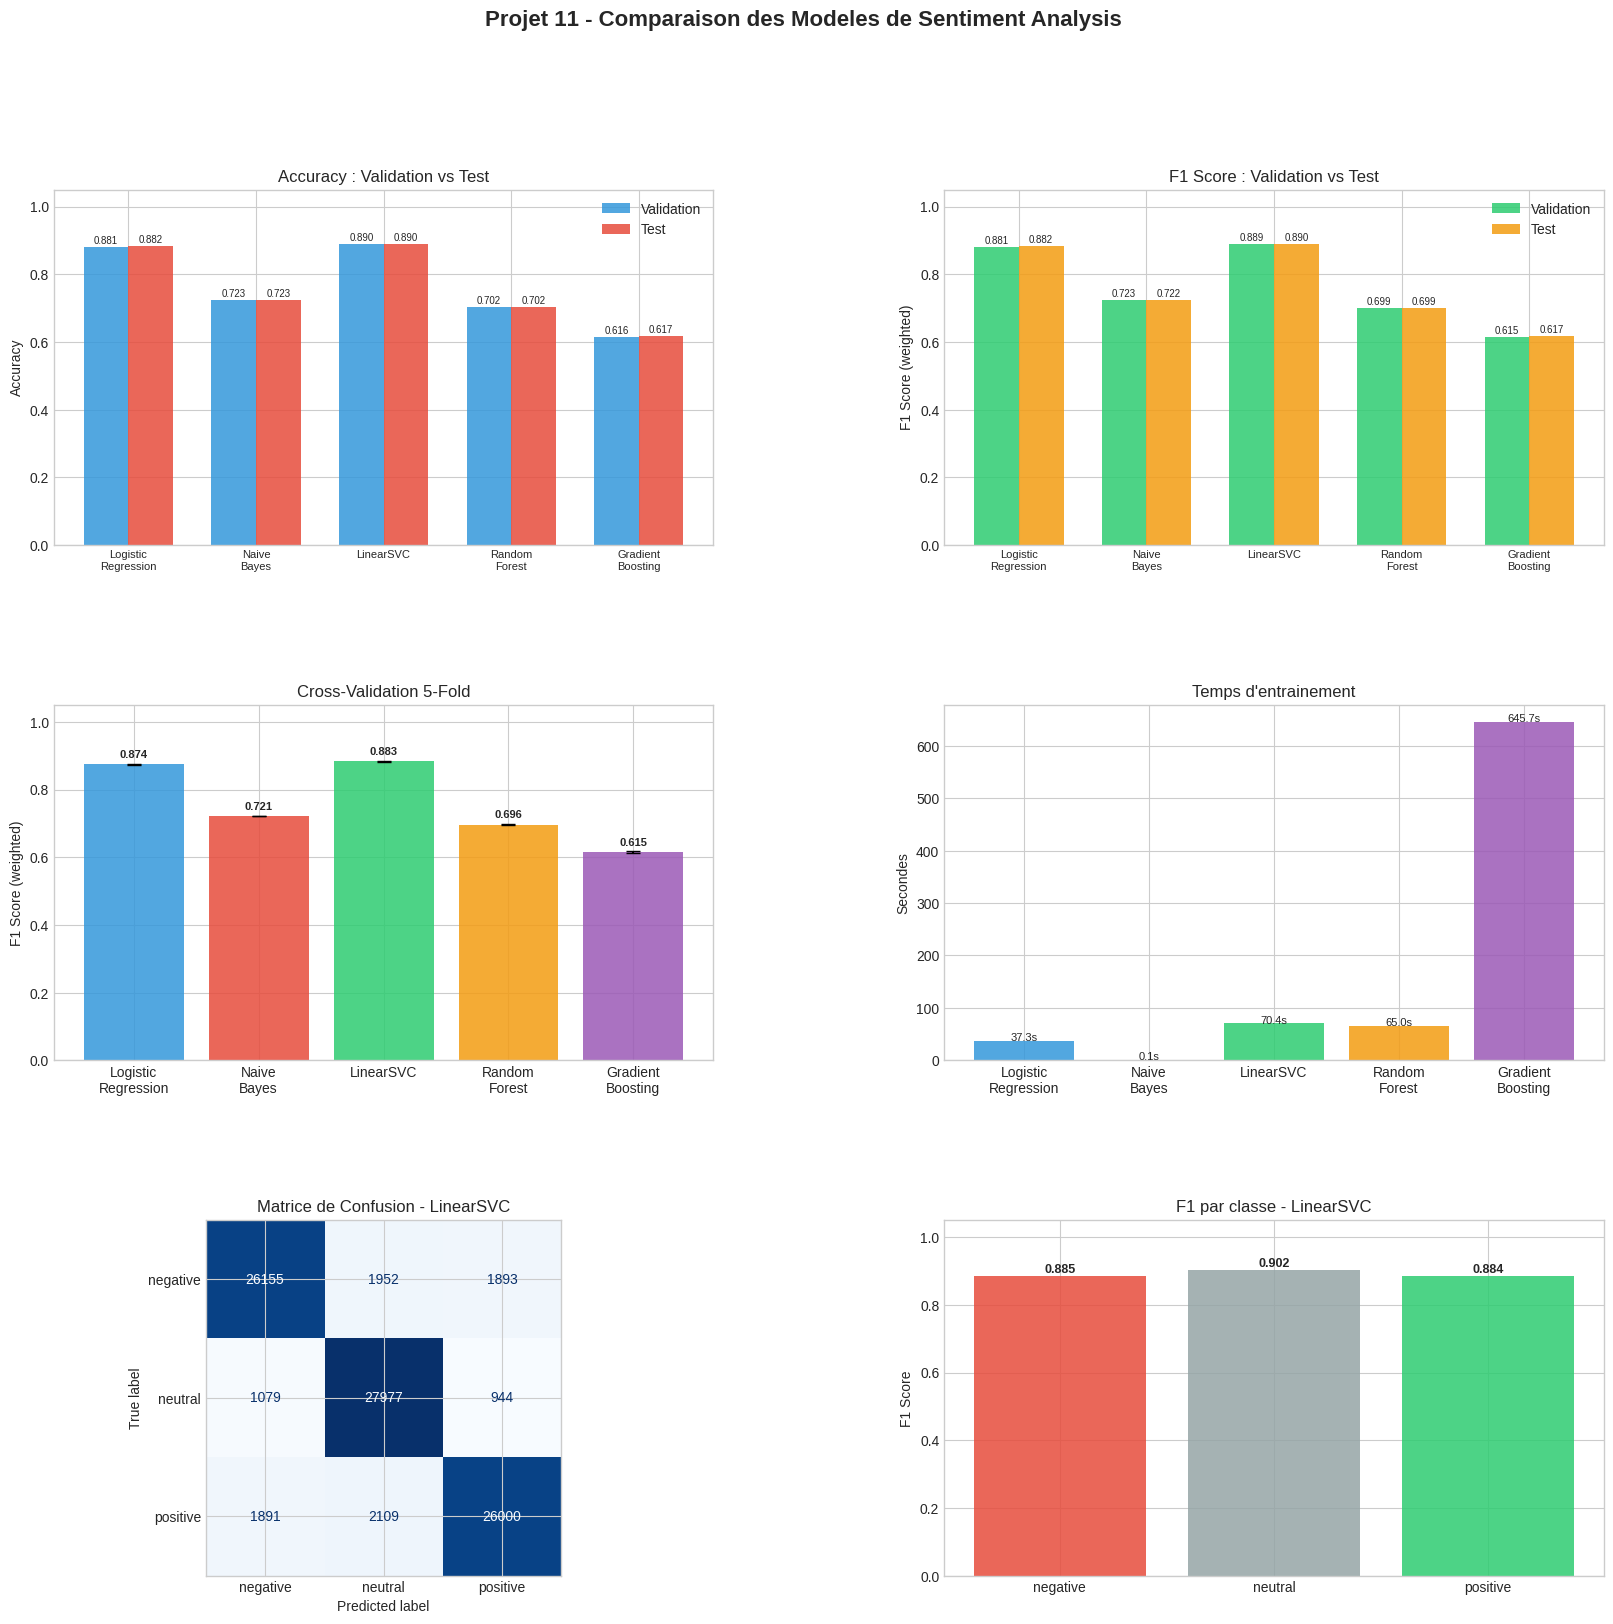

Visualisation sauvegardee : comparaison_modeles.png


In [13]:
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    'Projet 11 - Comparaison des Modeles de Sentiment Analysis',
    fontsize=16, fontweight='bold', y=0.98
)

model_names = list(results.keys())
palette     = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
short_names = [n.replace(' ', chr(10)) for n in model_names]
x, w = np.arange(len(model_names)), 0.35

acc_vals    = [results[m]['acc_val']    for m in model_names]
f1_vals     = [results[m]['f1_val']     for m in model_names]
acc_tests   = [results[m]['acc_test']   for m in model_names]
f1_tests    = [results[m]['f1_test']    for m in model_names]
cv_means    = [results[m]['cv_mean']    for m in model_names]
cv_stds     = [results[m]['cv_std']     for m in model_names]
train_times = [results[m]['train_time'] for m in model_names]

# Plot 1 - Accuracy Val vs Test
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x - w/2, acc_vals,  w, label='Validation', color='#3498db', alpha=0.85)
ax1.bar(x + w/2, acc_tests, w, label='Test',       color='#e74c3c', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(short_names, fontsize=8)
ax1.set_ylim(0, 1.05); ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy : Validation vs Test'); ax1.legend()
for i, (v, t) in enumerate(zip(acc_vals, acc_tests)):
    ax1.text(i-w/2, v+0.01, f'{v:.3f}', ha='center', fontsize=7)
    ax1.text(i+w/2, t+0.01, f'{t:.3f}', ha='center', fontsize=7)

# Plot 2 - F1 Val vs Test
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(x - w/2, f1_vals,  w, label='Validation', color='#2ecc71', alpha=0.85)
ax2.bar(x + w/2, f1_tests, w, label='Test',       color='#f39c12', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(short_names, fontsize=8)
ax2.set_ylim(0, 1.05); ax2.set_ylabel('F1 Score (weighted)')
ax2.set_title('F1 Score : Validation vs Test'); ax2.legend()
for i, (v, t) in enumerate(zip(f1_vals, f1_tests)):
    ax2.text(i-w/2, v+0.01, f'{v:.3f}', ha='center', fontsize=7)
    ax2.text(i+w/2, t+0.01, f'{t:.3f}', ha='center', fontsize=7)

# Plot 3 - Cross-Validation
ax3 = fig.add_subplot(gs[1, 0])
bars = ax3.bar(short_names, cv_means, color=palette, alpha=0.85, yerr=cv_stds, capsize=5)
ax3.set_ylim(0, 1.05); ax3.set_ylabel('F1 Score (weighted)')
ax3.set_title('Cross-Validation 5-Fold')
for bar, m in zip(bars, cv_means):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{m:.3f}', ha='center', fontsize=8, fontweight='bold')

# Plot 4 - Temps d'entrainement
ax4 = fig.add_subplot(gs[1, 1])
bars = ax4.bar(short_names, train_times, color=palette, alpha=0.85)
ax4.set_ylabel('Secondes'); ax4.set_title("Temps d'entrainement")
for bar, t in zip(bars, train_times):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{t:.1f}s', ha='center', fontsize=8)

# Plot 5 - Matrice de confusion
ax5 = fig.add_subplot(gs[2, 0])
cm = confusion_matrix(y_test, results[best_model]['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax5, colorbar=False, cmap='Blues')
ax5.set_title(f'Matrice de Confusion - {best_model}')

# Plot 6 - F1 par classe
ax6 = fig.add_subplot(gs[2, 1])
r = results[best_model]['report']
f1_per = [r[c]['f1-score'] for c in label_names]
bars = ax6.bar(label_names, f1_per, color=['#e74c3c','#95a5a6','#2ecc71'], alpha=0.85)
ax6.set_ylim(0,1.05); ax6.set_ylabel('F1 Score')
ax6.set_title(f'F1 par classe - {best_model}')
for bar, val in zip(bars, f1_per):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.savefig(REPORTS_DIR / 'comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisation sauvegardee : comparaison_modeles.png')

## Cellule 13 - Rapport final et instructions

In [14]:
lines = [
    'PROJET 11 - RAPPORT DE MODELISATION',
    f'Genere le : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    '',
    f'Dataset total       : {len(df):,} tweets',
    f'Apres echantillon   : {len(X_sampled):,} tweets',
    f'Train/Val/Test      : {len(X_train):,} / {len(X_val):,} / {len(X_test):,}',
    f'Vocabulaire TF-IDF  : {len(tfidf.vocabulary_):,} features (bigrammes)',
    '',
    'TABLEAU COMPARATIF',
    comparison_df.to_string(),
    '',
    f'MEILLEUR MODELE : {best_model}',
    f'F1 Test         : {best_f1:.4f}',
    '',
    'RAPPORT CLASSIFICATION - MEILLEUR MODELE',
    classification_report(y_test, results[best_model]['y_pred'], target_names=label_names),
]

for name, r in results.items():
    lines += [f'RAPPORT - {name}',
              classification_report(y_test, r['y_pred'], target_names=label_names), '']

txt = chr(10).join(lines)
print(txt)

with open(REPORTS_DIR / 'rapport_modelisation.txt', 'w', encoding='utf-8') as f:
    f.write(txt)

print()
print('Pipeline termine avec succes.')
print(f'Modeles dans    : {MODELS_DIR}')
print(f'Rapports dans   : {REPORTS_DIR}')

PROJET 11 - RAPPORT DE MODELISATION
Genere le : 2026-06-24 08:23:14

Dataset total       : 1,678,802 tweets
Apres echantillon   : 600,000 tweets
Train/Val/Test      : 420,000 / 90,000 / 90,000
Vocabulaire TF-IDF  : 50,000 features (bigrammes)

TABLEAU COMPARATIF
                     Accuracy (Val)  F1 (Val)  Accuracy (Test)  F1 (Test)  CV F1 Moy  CV F1 Std  Temps (s)
LinearSVC                    0.8896    0.8895           0.8904     0.8902     0.8835     0.0009      70.36
Logistic Regression          0.8815    0.8812           0.8824     0.8821     0.8739     0.0009      37.34
Naive Bayes                  0.7227    0.7226           0.7226     0.7224     0.7214     0.0008       0.07
Random Forest                0.7020    0.6991           0.7021     0.6994     0.6962     0.0025      64.97
Gradient Boosting            0.6157    0.6152           0.6171     0.6168     0.6153     0.0028     645.70

MEILLEUR MODELE : LinearSVC
F1 Test         : 0.8902

RAPPORT CLASSIFICATION - MEILLEUR MODELE

## Cellule 14 - Lancer MLflow UI en local (apres telechargement)

In [16]:
# INSTRUCTIONS POUR VISUALISER LES RESULTATS MLFLOW EN LOCAL
# Executez ce code pour afficher les commandes a suivre

instructions = """
ETAPES POUR VOIR L'INTERFACE MLFLOW :

1. Telecharger le dossier mlruns/ depuis Google Drive
   Chemin Drive : Mon Drive/NLP_Project/mlruns/
   Placer dans  dossier local: /NLP_Projet/mlruns/

2. Ouvrir un terminal Windows dans NLP_Projet/ :
   cd /NLP_Projet

3. Installer mlflow si pas deja fait :
   pip install mlflow

4. Lancer l'interface :
   mlflow ui --backend-store-uri ./mlruns

5. Ouvrir dans le navigateur :
   http://localhost:5000

Vous verrez :
   - Tous les runs (5 modeles + le run BEST_MODEL)
   - Tableau comparatif des metriques (F1, Accuracy, CV)
   - Graphiques d'evolution
   - Artifacts : modele, vectoriseur, rapport
   - Model Registry : Projet11_SentimentAnalysis v1
"""

print(instructions)

# Affichage du tableau comparatif final dans Colab
print('RESUME DES RUNS MLFLOW :')
print()
header = f'{"Modele":<22} {"F1 Val":>8} {"F1 Test":>8} {"CV Mean":>8} {"Temps(s)":>10}'
print(header)
print('-' * len(header))
for name, r in sorted(results.items(), key=lambda x: x[1]['f1_test'], reverse=True):
    marker = ' <- MEILLEUR' if name == best_model else ''
    print(f'{name:<22} {r["f1_val"]:>8.4f} {r["f1_test"]:>8.4f} {r["cv_mean"]:>8.4f} {r["train_time"]:>10.1f}s{marker}')



ETAPES POUR VOIR L'INTERFACE MLFLOW :

1. Telecharger le dossier mlruns/ depuis Google Drive
   Chemin Drive : Mon Drive/NLP_Project/mlruns/
   Placer dans  dossier local: /NLP_Projet/mlruns/

2. Ouvrir un terminal Windows dans NLP_Projet/ :
   cd /NLP_Projet

3. Installer mlflow si pas deja fait :
   pip install mlflow

4. Lancer l'interface :
   mlflow ui --backend-store-uri ./mlruns

5. Ouvrir dans le navigateur :
   http://localhost:5000

Vous verrez :
   - Tous les runs (5 modeles + le run BEST_MODEL)
   - Tableau comparatif des metriques (F1, Accuracy, CV)
   - Graphiques d'evolution
   - Artifacts : modele, vectoriseur, rapport
   - Model Registry : Projet11_SentimentAnalysis v1

RESUME DES RUNS MLFLOW :

Modele                   F1 Val  F1 Test  CV Mean   Temps(s)
------------------------------------------------------------
LinearSVC                0.8895   0.8902   0.8835       70.4s <- MEILLEUR
Logistic Regression      0.8812   0.8821   0.8739       37.3s
Naive Bayes        